In [7]:
# 2D radial space expansion simulation using Beverton-Holt model for 3 planets
# (model "Eball": "E" = finite-sites model, "b" = mutations are calculated per site, "all" = mutations are all selected, and split between deleterious and beneficial)
# ------------------------------------------------

using StatsBase, Distributions, Random, Plots

In [9]:
# Input parameters
# ------------------------------------------------
Random.seed!(1234)
BURN_IN_GEN_N = 1
TOTAL_GEN_N = 80

# Max coordinates of the population bounding space
# (population = disk)
R_MAX_BURN_IN = 0
R_MAX = 30

X_MAX = R_MAX
Y_MAX = R_MAX
X_START = R_MAX_BURN_IN
Y_START = R_MAX_BURN_IN

# Dimensions of the whole space
X_DIM = 2*X_MAX+1
Y_DIM = 2*Y_MAX+1

# Population parameters
INDIVS_AT_START = 3 # monoecious
DEMES_FULL_AT_START = 1
K_CAPACITY = 35
#INDIVS_EARTH_AT_START = trunc(Int,K_CAPACITY*4/5) # monoecious
R_PROLIF_RATE = 2
r_LOG_PROLIF_RATE = log(2)

# Gene parameters
LOCI_N = 1000
MUT_DELETER_RATE = 0.85
SEL_LOCI_N = trunc(Int,LOCI_N * MUT_DELETER_RATE)
MUT_RATE = 0.0001
M_MIG_RATE = 0.05
PLANET_MIG_RATE = 0.001
S_SELECT_COEF = 0.002
H_DOMIN_COEF = 0.5
possible_dirs = [[-1,0],[0,-1],[0,1],[1,0]] #[[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]]

earthcent = [X_MAX+1,Y_MAX+1]
mooncent = [X_MAX+1,Y_MAX+1]
marscent = [X_MAX+1,Y_MAX+1]

2-element Vector{Int64}:
 31
 31

In [8]:
@inbounds function old_get_muts(monosomes1,monosomes2)
    len = length(monosomes1)
    muts1 = 0
    muts2 = 0
    muts3 = 0
    fits = []
    
    for i in 1:len
        muts_AA_sel = 0
        muts_Aa_sel = 0
        muts_AA_nonsel = 0
        muts_Aa_nonsel = 0
        new_fitness = 1.0

        for j in 1:LOCI_N
            if monosomes1[i][j]==true && monosomes2[i][j]==true
                if j in selected_loci
                    muts_AA_sel += 1
                    new_fitness *= 1 - S_SELECT_COEF
                else
                    muts_AA_nonsel += 1
                    new_fitness *= 1 + S_SELECT_COEF
                end

            elseif monosomes1[i][j]==true || monosomes2[i][j]==true
                if j in selected_loci
                    muts_Aa_sel += 1
                    new_fitness *= 1 - H_DOMIN_COEF * S_SELECT_COEF
                else
                    muts_Aa_nonsel += 1
                    new_fitness *= 1 + H_DOMIN_COEF * S_SELECT_COEF
                end
            end
        end

        push!(fits,new_fitness)
        muts1 += muts_AA_sel + muts_AA_nonsel
        muts2 += muts_Aa_sel + muts_Aa_nonsel
        muts3 = LOCI_N - muts1 - muts2
    end

    muts1 /= len
    muts2 /= len
    muts3 /= len

    return muts1,muts2,muts3,fits
end

function get_cnts(deme_ms1, deme_ms2)
    fits = []
    cAA = zeros(LOCI_N)
    cAa = zeros(LOCI_N)
    caa = zeros(LOCI_N)

    for i in 1:length(deme_ms1)
        new_fitness = 1.0

        for j in 1:LOCI_N
            if deme_ms1[i][j] == true && deme_ms2[i][j] == true
                if j in selected_loci
                    new_fitness *= 1 - S_SELECT_COEF
                else
                    new_fitness *= 1 + S_SELECT_COEF
                end
                cAA[j] += 1

            elseif deme_ms1[i][j] == true || deme_ms2[i][j] == true
                if j in selected_loci
                    new_fitness *= 1 - H_DOMIN_COEF * S_SELECT_COEF
                else
                    new_fitness *= 1 + H_DOMIN_COEF * S_SELECT_COEF
                end
                cAa[j] += 1
            else
                caa[j] += 1
            end
        end

        push!(fits, new_fitness)
    end

    return cAA, cAa, caa, fits
end

@inbounds function mutate(monosome1,monosome2)
    @fastmath @inbounds for h in 1:LOCI_N

        if rand()<MUT_RATE
            monosome1[h] = true
        end
        if rand()<MUT_RATE
            monosome2[h] = true
        end
    end
end

@inbounds function crossover(monosome1,monosome2)
    for j in 1:LOCI_N
        lr = rand(1:2)
        monosome1[j] = lr==1 ? monosome1[j] : monosome2[j]
    end
end

@inbounds function mate_cond(mom_fit,dad_fit,max_fitness)
    return (mom_fit > rand()*max_fitness) & (dad_fit > rand()*max_fitness)
end


@inbounds function build_next_gen(wld_ms1,wld_ms2,r_max_migrate,planet="moon")
    # Determine the number of offspring for each deme
    next_gen_pops = zeros(Int16,X_DIM,Y_DIM)
    next_gen_posits = []
    fill!(next_gen_pops,-1)
    for x in 1:X_DIM,y in 1:Y_DIM
        if isassigned(wld_ms1,x,y) && length(wld_ms1[x,y])>0
            n_ppl_at_deme = length(wld_ms1[x,y])
            expected_offspring = n_ppl_at_deme * (R_PROLIF_RATE/(1 + (n_ppl_at_deme*(R_PROLIF_RATE-1))/K_CAPACITY))
            next_gen_pops[x,y] =  rand(Poisson(expected_offspring))
            #birth_chances[x] = 1 - expected_offspring/K_CAPACITY/R_PROLIF_RATE
            #println("x: $x, ",birth_chances[x])
            if next_gen_pops[x,y]>0
                push!(next_gen_posits,[x,y])
            end
        end
    end
    

    # Define the world (habitat)
    #wld_next = Array{Person}(undef,sum(next_gen_pops))
    wld_ms1_next = Array{Array{Array{Int}}}(undef,X_DIM,Y_DIM)
    wld_ms2_next = Array{Array{Array{Int}}}(undef,X_DIM,Y_DIM)
    for k in 1:X_DIM, j in 1:Y_DIM
        wld_ms1_next[k,j] = Array{Int,1}[]
        wld_ms2_next[k,j] = Array{Int,1}[]
    end
    
    all_birth_count = 0

    # Main generation cycle (algorithm)
    mean_fitn_wld = Array{Float32}(undef,X_DIM,Y_DIM)
    fill!(mean_fitn_wld,-1)
    pops_wld = zeros(Int32,X_DIM,Y_DIM)
    mutsAA_wld = Array{Array{Int}}(undef,X_DIM,Y_DIM)
    mutsAa_wld = Array{Array{Int}}(undef,X_DIM,Y_DIM)
    mutsaa_wld = Array{Array{Int}}(undef,X_DIM,Y_DIM)
    for k in 1:X_DIM, j in 1:Y_DIM
        mutsAA_wld[k,j] = Array{Int,1}[]
        mutsAa_wld[k,j] = Array{Int,1}[]
        mutsaa_wld[k,j] = Array{Int,1}[]
    end


    for deme in next_gen_posits
        monosomes1_at_pos = wld_ms1[deme...]
        monosomes2_at_pos = wld_ms2[deme...]
        fitns = []
        mutsAA_wld[deme...],mutsAa_wld[deme...],mutsaa_wld[deme...],fitns = get_cnts(monosomes1_at_pos,monosomes2_at_pos)
        mean_fitn_wld[deme...] = mean(fitns)
        max_fitness = maximum(fitns)
        sum_fitn = sum(fitns)
        fitns /= sum_fitn

        next_generation_size = next_gen_pops[deme...]
        
        if next_generation_size > 0
            birth_count = 0
            while birth_count < next_generation_size
                guyslen = length(monosomes1_at_pos)
                mom_id = rand(1:guyslen)
                dad_id = rand(1:guyslen)
                mom_fit = fitns[mom_id]
                dad_fit = fitns[dad_id]
                #println(mom_fit,"  ",dad_fit)

                #print(mate_cond(relative_extract_xx_ind,relative_extract_xy_ind,max_fitness))
                if mate_cond(mom_fit,dad_fit,max_fitness)
                    mom1 = copy(monosomes1_at_pos[mom_id])
                    mom2 = copy(monosomes2_at_pos[mom_id])
                    dad1 = copy(monosomes1_at_pos[dad_id])
                    dad2 = copy(monosomes2_at_pos[dad_id])
                    crossover(mom1,mom2)
                    crossover(dad1,dad2)
                    mutate(mom1,mom2)
                    mutate(dad1,dad2)

                    res_x = deme[1]
                    res_y = deme[2]
                    if rand()<M_MIG_RATE
                        dir = sample(possible_dirs)
                        move_x = dir[1]
                        move_y = dir[2]
                        x2 = (deme[1]-X_MAX-1+move_x)*(deme[1]-X_MAX-1+move_x)
                        y2 = (deme[2]-Y_MAX-1+move_y)*(deme[2]-Y_MAX-1+move_y)
                        r2 = x2+y2
                        if r2 > r_max_migrate*r_max_migrate
                            res_x = X_MAX+1-trunc(Int16,(r_max_migrate*r_max_migrate/r2) * move_x)
                            res_y = Y_MAX+1-trunc(Int16,(r_max_migrate*r_max_migrate/r2) * move_y)
                        else
                            res_x += move_x
                            res_y += move_y
                        end
                    elseif rand()<PLANET_MIG_RATE
                        if planet=="earth" && deme==earthcent
                            global w1_ms1, w1_ms2
                            push!(w1_ms1[mooncent...],mom1)
                            push!(w1_ms2[mooncent...],dad2)
                        elseif planet=="moon" && deme==mooncent
                            global w2_ms1, w2_ms2
                            push!(w2_ms1[marscent...],mom1)
                            push!(w2_ms2[marscent...],dad2)
                        elseif planet=="mars" && deme==marscent
                            global w1_ms1, w1_ms2
                            push!(w1_ms1[mooncent...],mom1)
                            push!(w1_ms2[mooncent...],dad2)
                        end
                    end
                    
                    global id_counter
                    #mom1[end-1] = id_counter
                    #dad2[end-1] = id_counter
                    id_counter += 1

                    push!(wld_ms1_next[res_x,res_y],mom1)
                    push!(wld_ms2_next[res_x,res_y],dad2)

                    birth_count += 1
                    all_birth_count += 1
                end
            end
            pops_wld[deme...] = birth_count
        end
    end
    return wld_ms1_next,wld_ms2_next,mean_fitn_wld,mutsAA_wld,mutsAa_wld,pops_wld
end

build_next_gen (generic function with 2 methods)

In [10]:
# Main program
# ------------------------------------------------
id_counter = 1
x_range = (X_MAX+1-X_START):(X_MAX+1+X_START)
y_range = (Y_MAX+1-Y_START):(Y_MAX+1+Y_START)
possible_init_coords = [collect(x) for x in Iterators.product(x_range, y_range)]
x_range2 = (X_MAX+1-4):(X_MAX+1+4)
y_range2 = (Y_MAX+1-4):(Y_MAX+1+4)
possible_init_coords2 = [collect(x) for x in Iterators.product(x_range2, y_range2)]
init_coords = sample(possible_init_coords,DEMES_FULL_AT_START;replace=false)

w0_ms1 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM) # array of all first homologous chromosomes (monosomes="ms") on Earth
w0_ms2 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM)
w1_ms1 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM) # array of all first homologous chromosomes (monosomes="ms") on Moon
w1_ms2 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM)
w2_ms1 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM) # array of all first homologous chromosomes (monosomes="ms") on Mars
w2_ms2 = Array{Array{Array{Bool}}}(undef,X_DIM,Y_DIM)

for k in 1:X_DIM, j in 1:Y_DIM
    w0_ms1[k,j] = Array{Array{Bool}}[]
    w0_ms2[k,j] = Array{Array{Bool}}[]
    w1_ms1[k,j] = Array{Array{Bool}}[]
    w1_ms2[k,j] = Array{Array{Bool}}[]
    w2_ms1[k,j] = Array{Array{Bool}}[]
    w2_ms2[k,j] = Array{Array{Bool}}[]
end
for coord in init_coords
    for i in 1:INDIVS_AT_START
        push!(w1_ms1[coord...],rand(0:1,LOCI_N))
        push!(w1_ms2[coord...],rand(0:1,LOCI_N))
        global id_counter+=1
    end
end
for coord in possible_init_coords2
    for i in 1:K_CAPACITY
        push!(w0_ms1[coord...],rand(0:1,LOCI_N))
        push!(w0_ms2[coord...],rand(0:1,LOCI_N))
        #global id_counter+=1
    end
end
selected_loci = randperm(LOCI_N)[1:SEL_LOCI_N]

850-element Vector{Int64}:
 429
 613
  73
 106
 858
 232
 814
 840
 494
 948
   ⋮
 457
 675
 962
 204
 908
 884
 288
 434
 870

In [11]:
# Iterate the main cycle and save the output
# ------------------------------------------------

meanf_w0 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAA_w0 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAa_w0= Array{Float32}(undef,X_DIM,Y_DIM,0)
#mutsaa_w0 = Array{Float32}(undef,X_DIM,Y_DIM,0)
pops_w0 = Array{Int32}(undef,X_DIM,Y_DIM,0)

meanf_w1 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAA_w1 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAa_w1 = Array{Float32}(undef,X_DIM,Y_DIM,0)
#mutsaa_w1 = Array{Float32}(undef,X_DIM,Y_DIM,0)
pops_w1 = Array{Int32}(undef,X_DIM,Y_DIM,0)

meanf_w2 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAA_w2 = Array{Float32}(undef,X_DIM,Y_DIM,0)
mutsAa_w2 = Array{Float32}(undef,X_DIM,Y_DIM,0)
#mutsaa_w2 = Array{Float32}(undef,X_DIM,Y_DIM,0)
pops_w2 = Array{Int32}(undef,X_DIM,Y_DIM,0)

@inbounds for _ in 1:BURN_IN_GEN_N
#=     global w0_ms1, w0_ms2,meanf,muts1,muts2,pops = build_next_gen(w0_ms1,w0_ms2,R_MAX_BURN_IN,"earth")
    global meanf_w0 = cat(meanf_w0,meanf, dims=3)
    global mutsAA_w0 = cat(mutsAa_w0, muts1, dims=3)
    global mutsAa_w0 = cat(mutsAa_w0, muts2, dims=3)
    global pops_w0 = cat(pops_w0,pops, dims=3) =#

    global w1_ms1, w1_ms2,meanf,muts1,muts2,pops = build_next_gen(w1_ms1,w1_ms2,R_MAX_BURN_IN,"moon")
    global meanf_w1 = cat(meanf_w1,meanf, dims=3)
    global mutsAA_w1 = cat(mutsAa_w1, muts1, dims=3)
    global mutsAa_w1 = cat(mutsAa_w1, muts2, dims=3)
    global pops_w1 = cat(pops_w1,pops, dims=3)

    global w2_ms1, w2_ms2,meanf,muts1,muts2,pops = build_next_gen(w2_ms1,w2_ms2,R_MAX_BURN_IN,"mars")
    global meanf_w2 = cat(meanf_w2,meanf, dims=3)
    global mutsAA_w2 = cat(mutsAA_w2, muts1, dims=3)
    global mutsAa_w2 = cat(mutsAa_w2, muts2, dims=3)
    global pops_w2 = cat(pops_w2,pops, dims=3)
end

@inbounds @time for _ in (BURN_IN_GEN_N+1):TOTAL_GEN_N
#=     global w0_ms1, w0_ms2,meanf,muts1,muts2,pops = build_next_gen(w0_ms1,w0_ms2,R_MAX,"earth")
    global meanf_w0 = cat(meanf_w0,meanf, dims=3)
    global mutsAA_w0 = cat(mutsAa_w0, muts1, dims=3)
    global mutsAa_w0 = cat(mutsAa_w0, muts2, dims=3)
    global pops_w0 = cat(pops_w0,pops, dims=3) =#

    global w1_ms1, w1_ms2,meanf,muts1,muts2,pops  = build_next_gen(w1_ms1,w1_ms2,R_MAX,"moon")
    global meanf_w1 = cat(meanf_w1,meanf, dims=3)
    global mutsAA_w1 = cat(mutsAA_w1, muts1, dims=3)
    global mutsAa_w1 = cat(mutsAa_w1, muts2, dims=3)
    global pops_w1 = cat(pops_w1,pops, dims=3)

    global w2_ms1, w2_ms2,meanf,muts1,muts2,pops = build_next_gen(w2_ms1,w2_ms2,R_MAX,"mars")
    global meanf_w2 = cat(meanf_w2,meanf, dims=3)
    global mutsAA_w2 = cat(mutsAA_w2, muts1, dims=3)
    global mutsAa_w2 = cat(mutsAa_w2, muts2, dims=3)
    global pops_w2 = cat(pops_w2,pops, dims=3)
end

println("Alive indivs: ",length(collect(Iterators.flatten(w1_ms1))))
println("Max indiv ID: ",maximum([maximum([k[end-1] for k in i]) for i in filter(!isempty,w1_ms1)]))

319.157739 seconds (7.29 G allocations: 169.044 GiB, 9.42% gc time, 0.07% compilation time)
Alive indivs: 16602
Max indiv ID: 1


┌ Info: Saved animation to C:\Users\LOCAL_~1\AppData\Local\Temp\jl_ElcJ85gZEp.gif
└ @ Plots C:\Users\local_axjynym\.julia\packages\Plots\Ec1L1\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\LOCAL_~1\\AppData\\Local\\Temp\\jl_ElcJ85gZEp.gif")
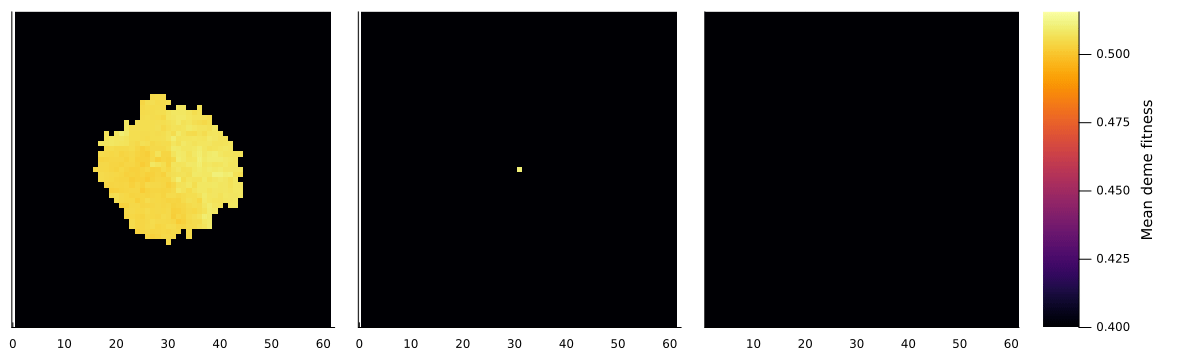

In [12]:
maxfitn = maximum(meanf_w1)
minfitn = minimum(meanf_w1)
#meanf_w1_norm = rescale(meanf_w1, (0,1))

slow_down = 1
gen_start = 1
gen_end = TOTAL_GEN_N

@gif for i=gen_start:(gen_end*slow_down-1)
    gen_no = trunc(Int,i/slow_down)+1
    h0 = heatmap(meanf_w1[:,:,end],aspect_ratio=1,yticks=false,clims=(0.4,maxfitn),xlabel="Earth",cbar=false)
    h1 = heatmap(meanf_w1[:,:,gen_no],aspect_ratio=1,yticks=false,clims=(0.4,maxfitn),xlabel="Moon",cbar=false)#,title="gen=$gen_no")
    h2 = heatmap(meanf_w2[:,:,gen_no],yticks=false,clims=(0.4,maxfitn),xlabel="Mars",colorbar_title="Mean deme fitness")
    p = plot(h0, h1, h2, layout=(@layout [a{0.29w} b{0.29w} c{0.39w} cbar]),seriestype = :heatmap,size=(1200,360))
end

In [14]:
function af_A(cnts_AA,cnts_Aa,locus)
    return (2*cnts_AA[locus]+cnts_Aa[locus])/LOCI_N
end

function twopq(cnts_AA,cnts_Aa,locus)
    a = af_A(cnts_AA,cnts_Aa,locus)
    return a*(1-a)*2
end

function pbar(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,locus)
    return (af_A(cnts_AA1,cnts_Aa1,locus)*pops1+af_A(cnts_AA2,cnts_Aa2,locus)*pops2)/(pops1+pops2)
end

function H_S(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,locus)
    return (twopq(cnts_AA1,cnts_Aa1,locus)*pops1+twopq(cnts_AA2,cnts_Aa2,locus)*pops2)/(pops1+pops2)
end

function H_T(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,l)
    a = pbar(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,l)
    return 2*a*(1-a)
end

function F_ST(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,locus)
    HT = H_T(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,locus)
    #println("HT=",HT)
    HS = H_S(cnts_AA1,cnts_Aa1,pops1,cnts_AA2,cnts_Aa2,pops2,locus)
    #println("HS=",HS)
    return (HT-HS)/HT
end

F_ST (generic function with 1 method)

In [15]:
mean(filter(!isnan,[F_ST(mutsAA_w1[mooncent...,end],mutsAa_w1[mooncent...,end],pops_w1[mooncent...,end],mutsAA_w2[marscent...,end],mutsAa_w2[marscent...,end],pops_w2[marscent...,end],l) for l in 1:LOCI_N])) #earthcent

0.0024703790734908046